# Augmentasyon Pipeline'ı ve Doğrulaması

`veri_manifest.csv`'yi girdi alır; üç eğitim notebook'unun da kullanacağı **Dataset + transform** tanımlarını üretir ve doğrular.

EDA'ya dayanan tasarım kararları:

| Karar | Gerekçe (EDA'dan) |
|---|---|
| `HorizontalFlip` var | Prob yönü zaten değişken, anatomik olarak serbest |
| **`VerticalFlip` yok** | Ultrasonda derinlik ekseni sabit — cilt üstte, derin doku altta. Dikey çevirme fiziksel olarak imkânsız bir görüntü üretir |
| Ölçek ±%15, dönme ±15° | Prob açısı ve cihaz derinlik ayarı farkları |
| Brightness/contrast ±0.2 | Görüntü ortalama parlaklığı veri setinde 30–170 arası; gain farkı gerçek |
| CLAHE yok | Vakaların %75'i hipoekoik; kontrastı yapay standardize etmek bu sinyali bozar |
| **Speckle noise** | Ultrasonun çarpımsal gürültü fiziği — toplamsal Gaussian'dan daha gerçekçi |
| **Motion blur** | Canlı akışta prob hareketinden kaynaklanan bulanık kareler; real-time hedefin doğrudan gereği |
| Akustik gölge yok | Lezyon üstüne denk geldiğinde "GT var ama görüntü yok" durumu yaratıyor |

**Ablasyon**: `hafif` ve `orta` olmak üzere iki yoğunluk tanımlı, seçilen bir mimaride karşılaştırılacak.

> Normalizasyon notu: burada görüntü `uint8` (0–255) olarak okunuyor, dolayısıyla `A.Normalize` **varsayılan `max_pixel_value=255.0` ile doğru**. Bu, `density_segmentation` projesindeki durumun tersi — orada görüntü Dataset içinde zaten `[0,1]`'e çekildiği için `max_pixel_value=1.0` gerekiyordu ve varsayılan bırakılması dinamik aralığı 255 kat daraltmıştı. Aşağıdaki doğrulama hücresi tensör aralığını basarak bunu kontrol ediyor.

In [1]:
!pip -q install albumentations

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, shutil, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

print('albumentations:', A.__version__)

VERI_DIR = '/content/drive/MyDrive/real_time_segmentasyon/veri'
DRIVE_DIR = '/content/drive/MyDrive/real_time_segmentasyon/augmentasyon'
LOCAL_DIR = '/content/outputs/augmentasyon'
LOCAL_DATA = '/content/dataset'

for d in [DRIVE_DIR, LOCAL_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

SEED = 42
IMAGE_SIZE = 256          # ana deney; ablasyonda 384
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def mirror_to_local(drive_path):
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)


manifest = pd.read_csv(f'{VERI_DIR}/veri_manifest.csv')
print('Manifest:', manifest.shape)
print(manifest.groupby(['split', 'cls']).size().unstack(fill_value=0).to_string())

Mounted at /content/drive
albumentations: 2.0.8
Manifest: (769, 12)
cls    benign  malignant  normal
split                           
test       65         31      19
train     300        146      92
val        65         31      20


## 1. Veri setini yerele kopyala

Her epoch 780 küçük PNG'yi Drive üzerinden okumak eğitimin en yavaş kısmı olur (density projesinde de aynı darboğaz `.npy` cache ile çözülmüştü). BUSI toplamda birkaç yüz MB, tek seferde `/content`'e kopyalanıp manifest yolları yerele çevriliyor.

In [3]:
DRIVE_DATA = '/content/drive/MyDrive/real_time_segmentasyon/Dataset_BUSI_with_GT'

if not os.path.isdir(LOCAL_DATA):
    t0 = time.time()
    shutil.copytree(DRIVE_DATA, LOCAL_DATA)
    print('Kopyalandi: %.1f sn' % (time.time() - t0))
else:
    print('Yerel kopya zaten var:', LOCAL_DATA)


def yerele_cevir(path_str):
    return path_str.replace(DRIVE_DATA, LOCAL_DATA)


manifest['image_path'] = manifest['image_path'].map(yerele_cevir)
manifest['mask_paths'] = manifest['mask_paths'].map(yerele_cevir)

eksik = [p for p in manifest['image_path'] if not os.path.exists(p)]
print('Bulunamayan goruntu:', len(eksik))
assert not eksik, eksik[:5]

Kopyalandi: 398.2 sn
Bulunamayan goruntu: 0


## 2. Transform tanımları

İki yoğunluk seviyesi. Ortak kısım: resize → normalize → tensor. Val/test tarafında **hiçbir** rastgelelik yok.

Albumentations sürümleri arasında `fill`/`cval` parametre adı değiştiği için doldurma argümanı hiç verilmiyor — her iki sürümde de varsayılan 0 (siyah), ultrasonda doğru davranış.

In [4]:
def son_adimlar(size):
    # goruntu uint8 (0-255) geldigi icin max_pixel_value varsayilan 255.0 dogru
    return [A.Resize(size, size),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=255.0),
            ToTensorV2()]


def train_transform(level='orta', size=IMAGE_SIZE):
    if level == 'hafif':
        aug = [
            A.HorizontalFlip(p=0.5),
            A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-10, 10), p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
        ]
    elif level == 'orta':
        aug = [
            A.HorizontalFlip(p=0.5),
            A.Affine(translate_percent=(-0.1, 0.1), scale=(0.85, 1.15), rotate=(-15, 15), p=0.7),
            A.ElasticTransform(alpha=30, sigma=6, p=0.25),      # prob basinci altinda doku deformasyonu
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.RandomGamma(gamma_limit=(80, 120), p=0.3),
            A.MultiplicativeNoise(multiplier=(0.85, 1.15), elementwise=True, p=0.3),  # speckle
            A.MotionBlur(blur_limit=7, p=0.2),                  # prob hareketi
        ]
    else:
        raise ValueError(f'bilinmeyen seviye: {level}')
    return A.Compose(aug + son_adimlar(size))


def eval_transform(size=IMAGE_SIZE):
    return A.Compose(son_adimlar(size))


AUG_LEVELS = ['hafif', 'orta']
for lv in AUG_LEVELS:
    t = train_transform(lv)
    print(f'{lv:6s}: {len(t.transforms)} adim ->',
          ', '.join(type(x).__name__ for x in t.transforms))

hafif : 6 adim -> HorizontalFlip, Affine, RandomBrightnessContrast, Resize, Normalize, ToTensorV2
orta  : 10 adim -> HorizontalFlip, Affine, ElasticTransform, RandomBrightnessContrast, RandomGamma, MultiplicativeNoise, MotionBlur, Resize, Normalize, ToTensorV2


## 3. Dataset

Üç eğitim notebook'u da bu sınıfı kullanacak. Çoklu maskeler burada da **birleşim** ile tek binary kanala indirgenir (EDA ile aynı tanım). Gri görüntü ImageNet ön-eğitimli encoder'lar için 3 kanala kopyalanır.

In [5]:
class BUSIDataset(Dataset):
    def __init__(self, manifest, split, transform):
        self.rows = manifest[manifest['split'] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def ham_oku(self, i):
        r = self.rows.iloc[i]
        img = cv2.imread(r['image_path'], cv2.IMREAD_GRAYSCALE)
        mask = np.zeros(img.shape, np.uint8)
        for mp in r['mask_paths'].split(';'):
            m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            if m.shape != img.shape:
                m = cv2.resize(m, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
            mask = np.maximum(mask, (m > 127).astype(np.uint8))
        return img, mask, r['case_id']

    def __getitem__(self, i):
        img, mask, _ = self.ham_oku(i)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)   # ImageNet encoder 3 kanal bekliyor
        out = self.transform(image=img, mask=mask)
        m = out['mask']
        if not torch.is_tensor(m):
            m = torch.from_numpy(m)
        return out['image'], m.unsqueeze(0).float()


ds_train = BUSIDataset(manifest, 'train', train_transform('orta'))
ds_val = BUSIDataset(manifest, 'val', eval_transform())
ds_test = BUSIDataset(manifest, 'test', eval_transform())
print('train/val/test:', len(ds_train), len(ds_val), len(ds_test))

x, y = ds_train[0]
print('goruntu:', tuple(x.shape), x.dtype, '| aralik [%.2f, %.2f]' % (x.min(), x.max()))
print('maske  :', tuple(y.shape), y.dtype, '| degerler', torch.unique(y).tolist())

train/val/test: 538 116 115
goruntu: (3, 256, 256) torch.float32 | aralik [-2.12, 1.56]
maske  : (1, 256, 256) torch.float32 | degerler [0.0, 1.0]


## 4. Görsel doğrulama

En kritik kontrol: geometrik dönüşümlerin görüntü ve maskeye **aynı** uygulanıp uygulanmadığı. Hizalama bozuksa loss anlamsız olur ama eğitim yine de "çalışıyor" görünür. Aşağıda maske konturu görüntünün üstüne çizili — lezyon sınırı her varyantta doğru yerde durmalı.

Ornek vaka: benign/benign (130)


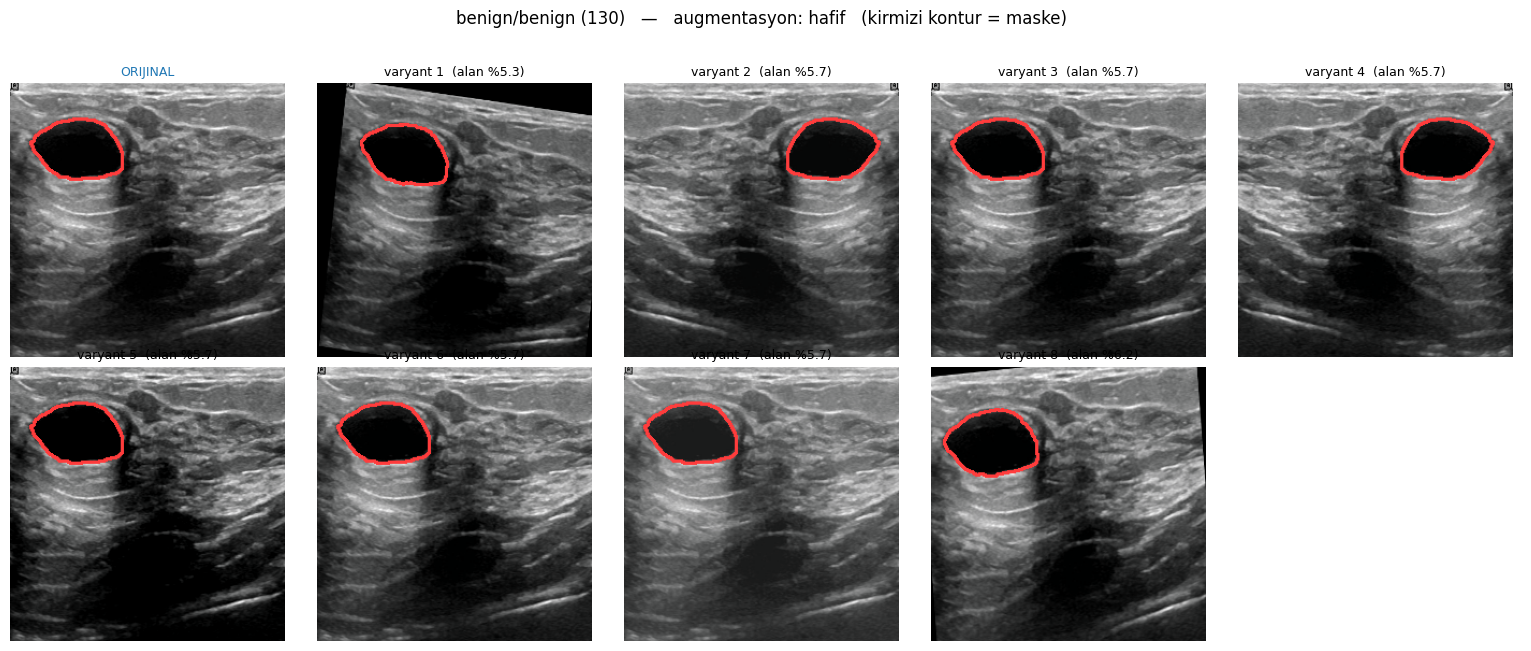

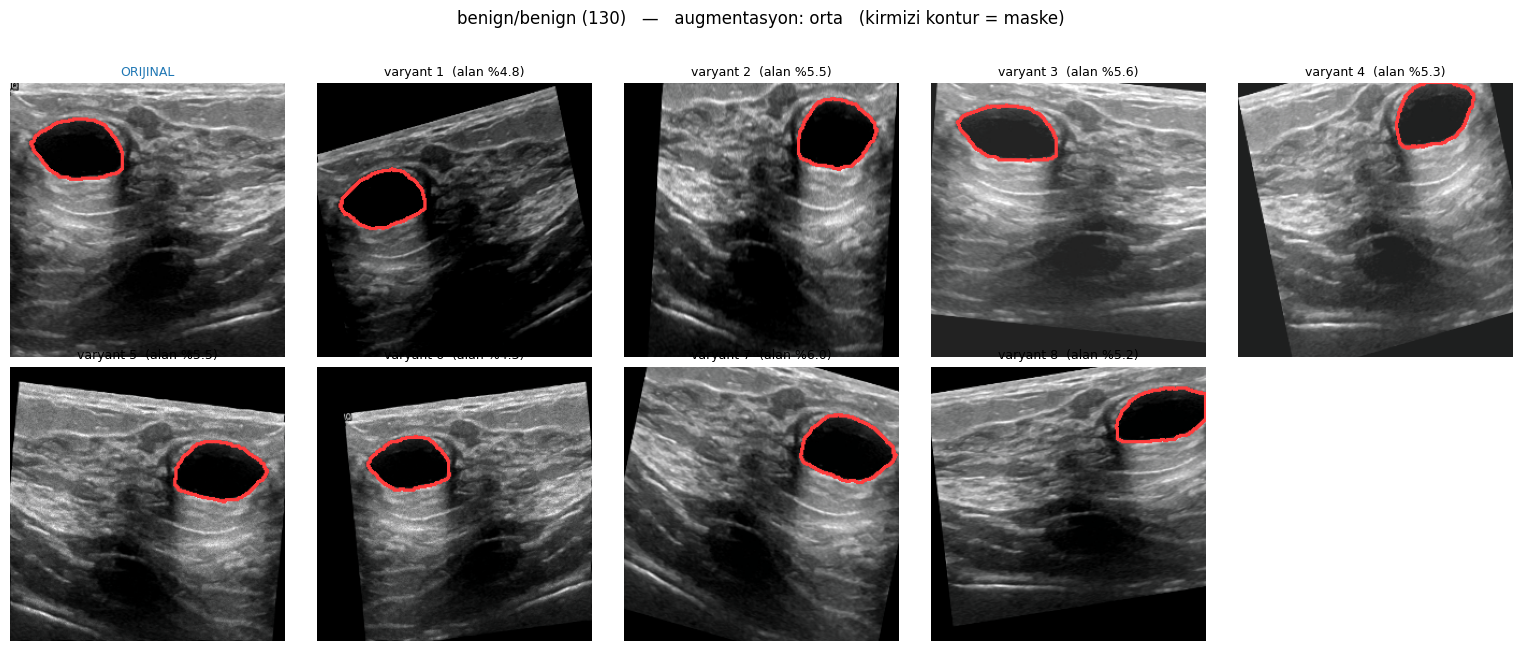

In [6]:
def tensordan_goruntu(x):
    # normalize edilmis tensoru gorsellestirmek icin geri cevir
    img = x.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img * 255, 0, 255).astype(np.uint8)


def kontur_ciz(img, mask):
    out = img.copy()
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, cnts, -1, (255, 60, 60), 2)
    return out


def varyant_gorseli(case_id, level, n=8, seed=SEED):
    row = manifest[manifest['case_id'] == case_id].iloc[0]
    tmp = BUSIDataset(manifest[manifest['case_id'] == case_id], row['split'], train_transform(level))
    img0, mask0, _ = tmp.ham_oku(0)

    fig, ax = plt.subplots(2, (n + 2) // 2, figsize=(3.1 * ((n + 2) // 2), 6.6))
    ax = ax.flatten()
    base = cv2.resize(cv2.cvtColor(img0, cv2.COLOR_GRAY2RGB), (IMAGE_SIZE, IMAGE_SIZE))
    bm = cv2.resize(mask0, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
    ax[0].imshow(kontur_ciz(base, bm)); ax[0].set_title('ORIJINAL', fontsize=9, color='tab:blue')
    ax[0].axis('off')

    torch.manual_seed(seed); np.random.seed(seed)
    for k in range(1, n + 1):
        x, y = tmp[0]
        m = y[0].numpy().astype(np.uint8)
        oran = 100 * m.mean()
        ax[k].imshow(kontur_ciz(tensordan_goruntu(x), m))
        ax[k].set_title(f'varyant {k}  (alan %{oran:.1f})', fontsize=9)
        ax[k].axis('off')
    for k in range(n + 1, len(ax)):
        ax[k].axis('off')

    plt.suptitle(f'{case_id}   —   augmentasyon: {level}   (kirmizi kontur = maske)', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    p = f'{DRIVE_DIR}/augment_varyantlar_{level}.png'
    plt.savefig(p, bbox_inches='tight'); mirror_to_local(p)
    plt.show()


# orta buyuklukte, tek lezyonlu temsilci bir train vakasi
aday = manifest[(manifest['split'] == 'train') & (manifest['lesion_px'] > 0) &
                (manifest['n_components'] == 1)].sort_values('lesion_ratio')
ORNEK = aday.iloc[len(aday) // 2]['case_id']
print('Ornek vaka:', ORNEK)

varyant_gorseli(ORNEK, 'hafif')
varyant_gorseli(ORNEK, 'orta')

## 5. Sayısal doğrulama

Görsel kontrol hizalamayı gösterir ama dağılımı göstermez. Bu hücre train setinin tamamı üzerinden birkaç tur augmentasyon çalıştırıp şunları ölçer:

1. **Tensör aralığı** — `[-2.1, 2.6]` civarında olmalı. Hepsi −2.1'e sıkışıksa normalizasyon iki kez uygulanmış demektir (density projesindeki ana bug).
2. **Maske ikiliği** — augmentasyon sonrası maske hâlâ yalnızca `{0,1}` içermeli; interpolasyon ara değer üretmemeli.
3. **Lezyon kaybı** — orijinalde lezyonlu olan bir görüntünün maskesi augmentasyon sonrası tamamen boşalıyorsa (kırpılıp gitmişse) o örnek eğitimde yanlış negatif sinyal verir. Bu oranın sıfıra yakın olması gerekir.
4. **Alan korunumu** — lezyon alan oranının augmentasyon öncesi/sonrası dağılımı.

In [7]:
def augment_dogrula(level, tur=3, seed=SEED):
    ds = BUSIDataset(manifest, 'train', train_transform(level))
    torch.manual_seed(seed); np.random.seed(seed)
    kayit = []
    gmin, gmax = np.inf, -np.inf
    ikili_ihlal = 0
    for t in range(tur):
        for i in range(len(ds)):
            x, y = ds[i]
            gmin, gmax = min(gmin, float(x.min())), max(gmax, float(x.max()))
            u = torch.unique(y)
            if not set(u.tolist()) <= {0.0, 1.0}:
                ikili_ihlal += 1
            kayit.append(dict(i=i, orijinal=ds.rows.iloc[i]['lesion_ratio'],
                              augment=float(y.mean())))
    k = pd.DataFrame(kayit)
    lezyonlu = k[k['orijinal'] > 0]
    kaybolan = int((lezyonlu['augment'] == 0).sum())
    return dict(seviye=level, ornek=len(k), tensor_min=round(gmin, 3), tensor_max=round(gmax, 3),
                ikili_ihlal=ikili_ihlal, lezyon_kaybi=kaybolan,
                lezyon_kaybi_yuzde=round(100 * kaybolan / len(lezyonlu), 2),
                alan_orani_medyan=round(float((lezyonlu['augment'] / lezyonlu['orijinal']).median()), 3)), k


sonuclar, kayitlar = [], {}
for lv in AUG_LEVELS:
    s, k = augment_dogrula(lv)
    sonuclar.append(s)
    kayitlar[lv] = k
    print(s)

dogrulama = pd.DataFrame(sonuclar)
print()
print(dogrulama.to_string(index=False))

assert dogrulama['ikili_ihlal'].sum() == 0, 'Maske ikili degerini kaybetti'
assert dogrulama['tensor_min'].min() > -3 and dogrulama['tensor_max'].max() < 3.5, 'Tensor araligi beklenmedik'
assert dogrulama['tensor_max'].max() - dogrulama['tensor_min'].min() > 3.0, \
    'Dinamik aralik cok dar - normalizasyon iki kez uygulanmis olabilir'
print('\nTum kontroller gecti.')

DOG_XLSX = f'{DRIVE_DIR}/augment_dogrulama.xlsx'
dogrulama.to_excel(DOG_XLSX, index=False)
mirror_to_local(DOG_XLSX)

{'seviye': 'hafif', 'ornek': 1614, 'tensor_min': -2.118, 'tensor_max': 2.64, 'ikili_ihlal': 0, 'lezyon_kaybi': 0, 'lezyon_kaybi_yuzde': 0.0, 'alan_orani_medyan': 1.0}
{'seviye': 'orta', 'ornek': 1614, 'tensor_min': -2.118, 'tensor_max': 2.64, 'ikili_ihlal': 0, 'lezyon_kaybi': 0, 'lezyon_kaybi_yuzde': 0.0, 'alan_orani_medyan': 0.999}

seviye  ornek  tensor_min  tensor_max  ikili_ihlal  lezyon_kaybi  lezyon_kaybi_yuzde  alan_orani_medyan
 hafif   1614      -2.118        2.64            0             0                 0.0              1.000
  orta   1614      -2.118        2.64            0             0                 0.0              0.999

Tum kontroller gecti.


'/content/outputs/augmentasyon/augment_dogrulama.xlsx'

### 5b. Hizalama testi (geometrik dönüşümler)

Yukarıdaki sayıların hiçbiri görüntü–maske hizalamasını test etmiyor: maske hiç dönüştürülmeseydi bile alan oranı ~1.0, lezyon kaybı 0 ve ikili ihlal 0 çıkardı.

Kesin test: görüntü kanalına **maskenin kendisi** besleniyor. Aynı `Compose` hem `image` hem `mask` argümanına uygulandığı için çıkan görüntü ile çıkan maske örtüşmek zorunda. Örtüşmüyorsa iki akış farklı geometri alıyor demektir.

İki ayrıntı testi anlamlı kılmak için gerekli:

1. **Yalnızca geometrik adımlar** kullanılıyor — fotometrik olanlar görüntüyü değiştirip maskeyi değiştirmediği için testi anlamsız kılardı.
2. **Test kopyasında her iki akış da nearest interpolasyon** kullanıyor. Gerçek pipeline görüntüde bilineer kullanır (doğrusu budur), ama bilineer sonucu eşikleyip nearest maskeyle karşılaştırmak tek başına IoU'yu ~0.97'ye düşürüyor (çapı 40 px altındaki lezyonlarda 0.935) — bu interpolasyon farkı, ölçmek istediğimiz geometri uyuşmazlığını gizler. Nearest–nearest karşılaştırmada beklenen değer **tam 1.0**; sapma varsa gerçek hizalama hatası demektir.

Ek olarak interpolasyondan bağımsız ikinci bir ölçü: lezyon **merkezlerinin** piksel cinsinden mesafesi.

In [13]:
import copy

GEOMETRIK = {'HorizontalFlip', 'Affine', 'ElasticTransform'}


def merkez(binary):
    ys, xs = np.nonzero(binary)
    return (np.nan, np.nan) if not len(xs) else (xs.mean(), ys.mean())


def hizalama_testi(level, n=150, seed=SEED):
    # test kopyasinda her iki akis da nearest: interpolasyon farki olcumu kirletmesin
    geo = [copy.deepcopy(t) for t in train_transform(level).transforms
           if type(t).__name__ in GEOMETRIK]
    for t in geo:
        if hasattr(t, 'interpolation'):
            t.interpolation = cv2.INTER_NEAREST
    comp = A.Compose(geo + [A.Resize(IMAGE_SIZE, IMAGE_SIZE, interpolation=cv2.INTER_NEAREST)])
    ds = BUSIDataset(manifest, 'train', comp)

    rng = np.random.RandomState(seed)
    lezyonlu = np.where(ds.rows['lesion_px'].to_numpy() > 0)[0]
    idx = rng.choice(lezyonlu, size=min(n, len(lezyonlu)), replace=False)

    iou, mesafe = [], []
    for i in idx:
        _, mask, _ = ds.ham_oku(int(i))
        sahte = np.stack([mask * 255] * 3, -1)      # goruntu kanali = maskenin kendisi
        out = comp(image=sahte, mask=mask)
        a = out['image'][..., 0] > 127
        b = out['mask'] > 0

        birlesim = int(np.logical_or(a, b).sum())
        iou.append(int(np.logical_and(a, b).sum()) / birlesim if birlesim else 1.0)

        (ax, ay), (bx, by) = merkez(a), merkez(b)
        mesafe.append(np.hypot(ax - bx, ay - by) if np.isfinite(ax) and np.isfinite(bx) else 0.0)
    return np.array(iou), np.array(mesafe)


hiz_rows = []
for lv in AUG_LEVELS:
    iou, mesafe = hizalama_testi(lv)
    row = dict(seviye=lv, ornek=len(iou),
               iou_medyan=round(float(np.median(iou)), 5),
               iou_min=round(float(iou.min()), 5),
               merkez_mesafe_medyan_px=round(float(np.median(mesafe)), 3),
               merkez_mesafe_max_px=round(float(mesafe.max()), 3))
    hiz_rows.append(row)
    print(row)          # assert'ten once basilir ki hata halinde sayilar gorunsun

hizalama = pd.DataFrame(hiz_rows)
print()
print(hizalama.to_string(index=False))

assert (hizalama['iou_medyan'] > 0.999).all(), 'goruntu ve maske farkli geometri aliyor'
assert (hizalama['merkez_mesafe_max_px'] < 1.0).all(), 'lezyon merkezleri ortusmuyor'
print('\nHizalama dogrulandi: her iki akis da ayni geometrik donusumu aliyor.')

{'seviye': 'hafif', 'ornek': 150, 'iou_medyan': 1.0, 'iou_min': 1.0, 'merkez_mesafe_medyan_px': 0.0, 'merkez_mesafe_max_px': 0.0}
{'seviye': 'orta', 'ornek': 150, 'iou_medyan': 1.0, 'iou_min': 1.0, 'merkez_mesafe_medyan_px': 0.0, 'merkez_mesafe_max_px': 0.0}

seviye  ornek  iou_medyan  iou_min  merkez_mesafe_medyan_px  merkez_mesafe_max_px
 hafif    150         1.0      1.0                      0.0                   0.0
  orta    150         1.0      1.0                      0.0                   0.0

Hizalama dogrulandi: her iki akis da ayni geometrik donusumu aliyor.


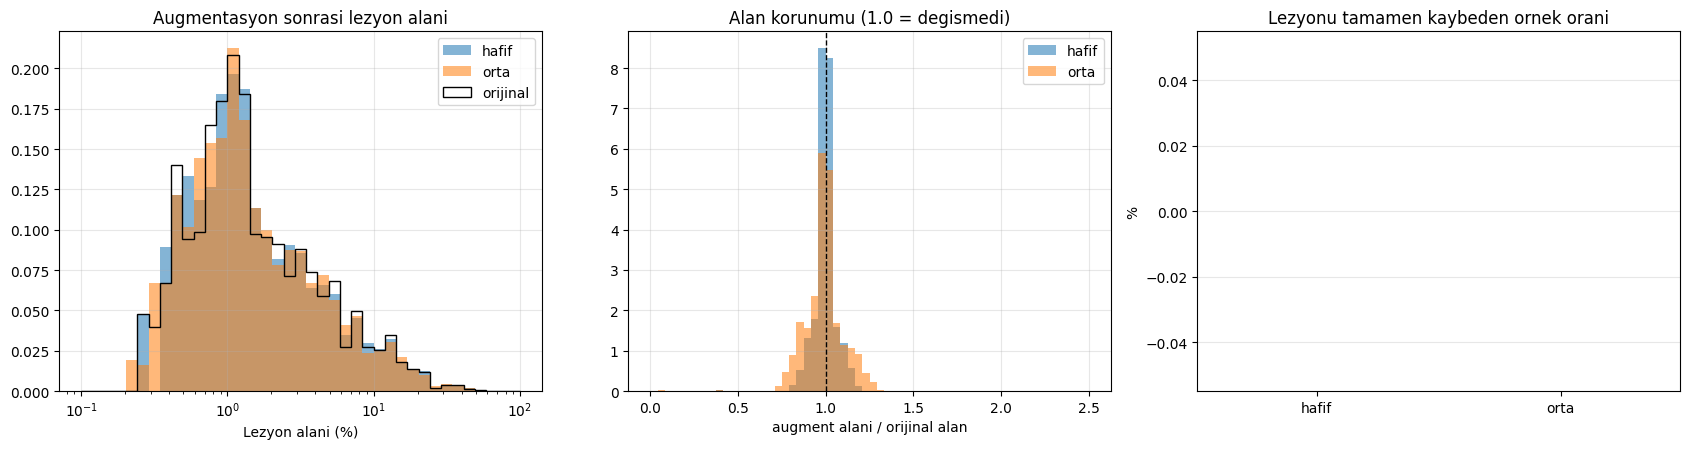

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
renk = {'hafif': 'tab:blue', 'orta': 'tab:orange'}

for lv in AUG_LEVELS:
    k = kayitlar[lv]
    lezyonlu = k[k['orijinal'] > 0]
    ax[0].hist(100 * lezyonlu['augment'], bins=np.logspace(-1, 2, 40), alpha=0.55,
               label=lv, color=renk[lv], density=True)
orij = manifest[(manifest['split'] == 'train') & (manifest['lesion_px'] > 0)]['lesion_ratio'] * 100
ax[0].hist(orij, bins=np.logspace(-1, 2, 40), histtype='step', color='k', lw=1.5,
           label='orijinal', density=True)
ax[0].set_xscale('log'); ax[0].set_xlabel('Lezyon alani (%)')
ax[0].set_title('Augmentasyon sonrasi lezyon alani'); ax[0].legend(); ax[0].grid(alpha=0.3)

for lv in AUG_LEVELS:
    k = kayitlar[lv]
    lezyonlu = k[k['orijinal'] > 0]
    ax[1].hist(lezyonlu['augment'] / lezyonlu['orijinal'], bins=60, range=(0, 2.5),
               alpha=0.55, label=lv, color=renk[lv], density=True)
ax[1].axvline(1.0, color='k', ls='--', lw=1)
ax[1].set_xlabel('augment alani / orijinal alan')
ax[1].set_title('Alan korunumu (1.0 = degismedi)'); ax[1].legend(); ax[1].grid(alpha=0.3)

x = np.arange(len(AUG_LEVELS))
ax[2].bar(x, dogrulama['lezyon_kaybi_yuzde'], color=[renk[l] for l in AUG_LEVELS])
ax[2].set_xticks(x); ax[2].set_xticklabels(AUG_LEVELS)
ax[2].set_ylabel('%'); ax[2].set_title('Lezyonu tamamen kaybeden ornek orani')
ax[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
FIG = f'{DRIVE_DIR}/augment_dogrulama.png'
plt.savefig(FIG, bbox_inches='tight'); mirror_to_local(FIG)
plt.show()

## 6. DataLoader hız testi

Real-time hedefli bir projede veri yükleme darboğaz olmamalı — GPU beklerse ölçtüğümüz eğitim süresi mimarinin değil disk/CPU'nun süresi olur.

In [15]:
for nw in [2, 4]:
    dl = DataLoader(BUSIDataset(manifest, 'train', train_transform('orta')),
                    batch_size=16, shuffle=True, num_workers=nw, pin_memory=True, drop_last=True)
    t0 = time.time()
    n = 0
    for xb, yb in dl:
        n += xb.shape[0]
    dt = time.time() - t0
    print(f'num_workers={nw}: {n} ornek / {dt:.1f} sn = {n/dt:.0f} ornek/sn  '
          f'(epoch basina ~{dt:.1f} sn veri yukleme)')

num_workers=2: 528 ornek / 11.8 sn = 45 ornek/sn  (epoch basina ~11.8 sn veri yukleme)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


num_workers=4: 528 ornek / 10.9 sn = 49 ornek/sn  (epoch basina ~10.9 sn veri yukleme)


## 7. Rapor

In [ ]:
def md_table(frame):
    cols = list(frame.columns)
    out = ['| ' + ' | '.join(str(c) for c in cols) + ' |', '|' + '---|' * len(cols)]
    for _, r in frame.iterrows():
        out.append('| ' + ' | '.join(str(r[c]) for c in cols) + ' |')
    return '\n'.join(out)


L = []
L.append('# Augmentasyon Raporu\n')
L.append(f'Girdi boyutu: {IMAGE_SIZE}x{IMAGE_SIZE} | albumentations {A.__version__} | seed {SEED}\n')
L.append(f'Train {len(ds_train)} | Val {len(ds_val)} | Test {len(ds_test)}\n')

L.append('\n## Transform zincirleri\n')
for lv in AUG_LEVELS:
    t = train_transform(lv)
    L.append(f'\n**{lv}**\n')
    for tr in t.transforms:
        L.append(f'- `{type(tr).__name__}` p={getattr(tr, "p", "-")}')
L.append('\n**val / test** (rastgelelik yok)\n')
for tr in eval_transform().transforms:
    L.append(f'- `{type(tr).__name__}`')

L.append('\n## Doğrulama\n')
L.append(md_table(dogrulama))
L.append('\n- `tensor_min/max`: normalize edilmiş girdi aralığı; ~[-2.1, 2.6] beklenir')
L.append('- `ikili_ihlal`: maskede {0,1} dışı değer üreten örnek sayısı (0 olmalı)')
L.append('- `lezyon_kaybi`: orijinalde lezyonlu iken augmentasyon sonrası maskesi tamamen boşalan örnek')
L.append('- `alan_orani_medyan`: augment alanı / orijinal alan; 1.0 civarı beklenir')

L.append('\n### Görüntü–maske hizalama testi\n')
L.append('Görüntü kanalına maskenin kendisi beslenip çıkan görüntü ile çıkan maskenin IoU\'su ölçülür; '
         'iki akış farklı geometri alsaydı bu değer çökerdi. Testte her iki akış da nearest '
         'interpolasyon kullanır, dolayısıyla beklenen değer tam 1.0.\n')
L.append('> Gerçek pipeline görüntüde bilineer, maskede nearest kullanır (doğrusu budur). Bu fark tek '
         'başına IoU\'yu ~0.97\'ye düşürdüğü için testte dışarıda bırakıldı; aksi halde ölçüm '
         'interpolasyon farkını geometri uyuşmazlığı sanardı. `merkez_mesafe` sütunu interpolasyondan '
         'bağımsız ikinci kontrol.\n')
L.append(md_table(hizalama))

L.append('\n## Tasarım gerekçeleri\n')
L.append('- VerticalFlip **yok**: ultrasonda derinlik ekseni sabit (cilt üstte), dikey çevirme fiziksel olarak imkânsız görüntü üretir')
L.append('- CLAHE **yok**: vakaların %75.4\'ü hipoekoik, kontrast standardizasyonu bu sinyali bozar')
L.append('- Speckle (MultiplicativeNoise) ve MotionBlur: canlı ultrason akışının gerçek bozulmaları, real-time dağıtım robustluğu için')
L.append('- Akustik gölge simülasyonu **yok**: lezyon üstüne denk geldiğinde GT ile görüntü çelişir')

report = '\n'.join(L)
REPORT_MD = f'{DRIVE_DIR}/augmentasyon_raporu.md'
Path(REPORT_MD).write_text(report, encoding='utf-8')
mirror_to_local(REPORT_MD)
print(report)